   disease  yellow_spots  brown_spots  wilting  powder  leaf_holes  humidity  \
0  Healthy             0            0        0       0           0        55   
1     Rust             1            0        0       0           0        70   
2     Rust             1            0        0       0           0        72   
3   Blight             1            1        1       0           0        85   
4   Blight             1            1        1       0           0        88   

   temperature  
0           29  
1           24  
2           25  
3           30  
4           31  
Explained variance: [0.47898842 0.30831767]
        disease  cluster
0       Healthy        1
1          Rust        1
2          Rust        1
3        Blight        0
4        Blight        0
5        Mildew        1
6        Mildew        1
7   Caterpillar        1
8   Caterpillar        1
9       Healthy        1
10       Blight        0
11         Rust        1
Accuracy: 0.25


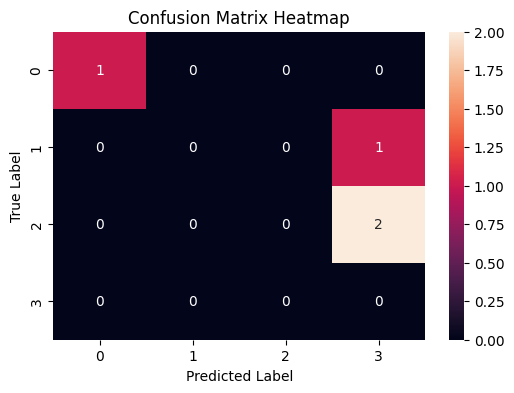

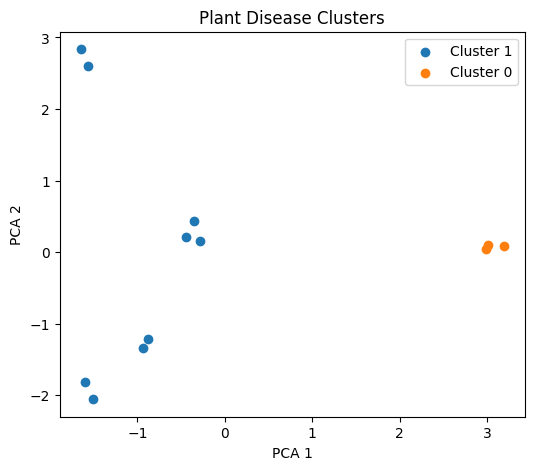

Cluster: 0
Predicted disease: Blight


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from cProfile import label
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns


data = {
    "disease": [
        "Healthy","Rust","Rust","Blight","Blight","Mildew","Mildew",
        "Caterpillar","Caterpillar","Healthy","Blight","Rust"
    ],
    "yellow_spots":[0,1,1,1,1,0,0,0,0,0,1,1],
    "brown_spots":[0,0,0,1,1,0,0,0,0,0,1,0],
    "wilting":[0,0,0,1,1,0,0,0,0,0,1,0],
    "powder":[0,0,0,0,0,1,1,0,0,0,0,0],
    "leaf_holes":[0,0,0,0,0,0,0,1,1,0,0,0],
    "humidity":[55,70,72,85,88,92,90,60,62,58,84,75],
    "temperature":[29,24,25,30,31,22,23,28,27,29,30,24]
}

df = pd.DataFrame(data)
print(df.head())
lebal = LabelEncoder()
df['target'] = lebal.fit_transform(df["disease"])
#Split features and target
X =df.drop(['disease','target'],axis=1)
y=df["target"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print('='*30)
print("Explained variance:", pca.explained_variance_ratio_)
print('='*30)
Kmeans = KMeans(n_clusters=2, random_state=42)
clusters = Kmeans.fit_predict(X_scaled)
df["cluster"] = clusters
print(df[["disease","cluster"]])

#Supervised learning KNN classifier
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.3,random_state=42)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train,y_train)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

conf_matrix = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 4)) # Sets the figure size
sns.heatmap(conf_matrix, annot=True, fmt='d') # Creates the heatmap with annotations

# Optional: Add labels and title for clarity
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()



df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1] 

plt.figure(figsize=(6,5))
for group in df['cluster'].unique():
    group_data = df[df['cluster']==group]
    plt.scatter(group_data['pca1'], group_data['pca2'], label=f"Cluster {group}")

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Plant Disease Clusters')
plt.legend()
plt.show()
# centroids = scaler.inverse_transform(model.cluster_centers_)
# plt.scatter(centroids[:,0], centroids[:,1], s=200, marker='X', label='Centroids')


sample = [[1,1,1,0,0,85,30]]

sample_scaled = scaler.transform(sample)

cluster = Kmeans.predict(sample_scaled)
pred_class = model.predict(sample_scaled)

print("Cluster:", cluster[0])
print("Predicted disease:", lebal.inverse_transform(pred_class)[0])

